In [1]:
# Importing all important packages and opening the zarr file
import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib import colors, patches
import matplotlib.image as mpimg
import zarr
import random
import sys
import zipfile
import io
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# Colormaps for both datasets
colors_phiSat = ['green', 'red', 'lightgray', 'blue']
my_cmap_phiSat = ListedColormap(colors_phiSat)

box_0_phiSat = mpatches.Patch(color=colors_phiSat[0], label='0: Background')
box_1_phiSat = mpatches.Patch(color=colors_phiSat[1], label='1: Burned area')
box_2_phiSat = mpatches.Patch(color=colors_phiSat[2], label='2: Clouds')
box_3_phiSat = mpatches.Patch(color=colors_phiSat[3], label='3: Water')
legend_phiSat = [box_0_phiSat, box_1_phiSat, box_2_phiSat, box_3_phiSat]

In [2]:
# Load data (from 01a_Preprocessing_PhiSat2.ipynb)
bewerkte_data_dir = '/home/laura/Scriptie/bewerkte_data/BurntArea'

X_dataset = np.load(os.path.join(bewerkte_data_dir, 'X_train_flat.npy'))
y_dataset = np.load(os.path.join(bewerkte_data_dir, 'y_train_flat.npy'))

# Subsampling (to not crash kernel)
train_set_size = min(100000, int(len(X_dataset) * 0.7))
test_set_size = min(50000, int(len(X_dataset) * 0.3))

X_train, X_test, y_train, y_test = train_test_split(
    X_dataset, 
    y_dataset, 
    train_size=train_set_size, 
    test_size=test_set_size, 
    random_state=42)

all_classes = np.unique(y_test)
names = ["0: Background", "1: Burned area", "2: Clouds", "3: Water"]

In [3]:
# ==========================================
# --- RANDOM FOREST MODEL ---
# ==========================================

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"\n--- RANDOM FOREST RESULTS ---")
print(f"Test Accuracy: {rf_accuracy*100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, rf_predictions, labels=all_classes, target_names=names, zero_division=0))



--- RANDOM FOREST RESULTS ---
Test Accuracy: 96.43%
Classification Report:
                precision    recall  f1-score   support

 0: Background       0.95      0.97      0.96     20947
1: Burned area       0.97      0.92      0.95     12303
     2: Clouds       0.98      0.99      0.99     16750

      accuracy                           0.96     50000
     macro avg       0.97      0.96      0.96     50000
  weighted avg       0.96      0.96      0.96     50000



/home/laura/Scriptie/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2964: UserWarning: labels size, 3, does not match size of target_names, 4
  warnings.warn(


In [4]:
# ==========================================
# --- XGBOOST MODEL ---
# ==========================================

dummy_X = np.zeros((4, X_train.shape[1]))
dummy_y = np.array([0, 1, 2, 3])

X_train_xgb = np.vstack((X_train, dummy_X))
y_train_xgb = np.concatenate((y_train, dummy_y))

xgb_model = XGBClassifier(n_estimators=50, max_depth=6, learning_rate=1, n_jobs=-1, random_state=42)
xgb_model.fit(X_train_xgb, y_train_xgb)

xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print(f"\n--- XGBOOST RESULTS ---")
print(f"Test Accuracy: {xgb_accuracy*100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, xgb_predictions, labels=all_classes, target_names=names, zero_division=0))



--- XGBOOST RESULTS ---
Test Accuracy: 96.01%
Classification Report:
                precision    recall  f1-score   support

 0: Background       0.95      0.96      0.95     20947
1: Burned area       0.95      0.93      0.94     12303
     2: Clouds       0.98      0.99      0.98     16750

      accuracy                           0.96     50000
     macro avg       0.96      0.96      0.96     50000
  weighted avg       0.96      0.96      0.96     50000



/home/laura/Scriptie/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2964: UserWarning: labels size, 3, does not match size of target_names, 4
  warnings.warn(


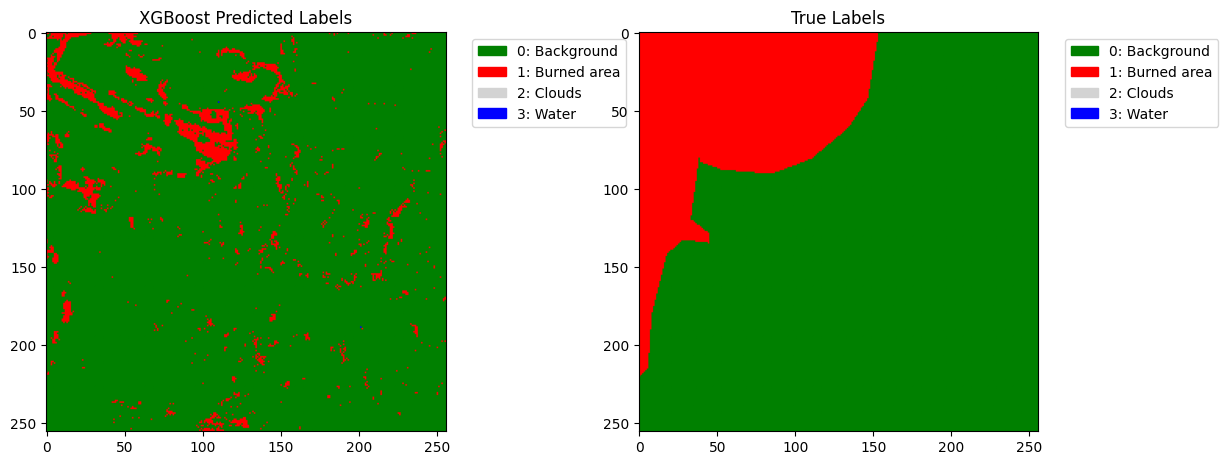

In [5]:
# ==========================================
# --- VISUALIZATION ---
# ==========================================
zarr_path = "/home/laura/Scriptie/ruwe_data/burned.zarr.zip"
store_phiSat2 = zarr.ZipStore(zarr_path, mode='r')

test_visual_id = "0007783"

image_visual = np.array(zarr.open_array(store_phiSat2, path=f"trainval/{test_visual_id}/img", mode='r'))
label_visual = np.array(zarr.open_array(store_phiSat2, path=f"trainval/{test_visual_id}/label", mode='r'))
store_phiSat2.close()

if len(label_visual.shape) == 3:
    flat_label_visual = np.argmax(label_visual, axis=0)

X_visual = np.moveaxis(image_visual, 0, -1).reshape(-1, image_visual.shape[0])

#prediction_visual = rf_model.predict(X_visual).reshape(flat_label_visual.shape)
prediction_visual = xgb_model.predict(X_visual).reshape(flat_label_visual.shape)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(prediction_visual, cmap=my_cmap_phiSat, vmin=0, vmax=len(colors_phiSat)-1)
plt.title('XGBoost Predicted Labels')
plt.legend(handles=[box_0_phiSat, box_1_phiSat, box_2_phiSat, box_3_phiSat], 
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(1, 2, 2)
plt.imshow(flat_label_visual, cmap=my_cmap_phiSat, vmin=0, vmax=len(colors_phiSat)-1)
plt.title('True Labels')
plt.legend(handles=[box_0_phiSat, box_1_phiSat, box_2_phiSat, box_3_phiSat], 
           bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [6]:
# Save data
bewerkte_data_dir = '/home/laura/Scriptie/bewerkte_data/PhiSat2'

np.save(os.path.join(bewerkte_data_dir, 'y_test_masks.npy'), y_test)

rf_probs = rf_model.predict_proba(X_test)[:, 1] 
np.save(os.path.join(bewerkte_data_dir, 'y_pred_masks_rf.npy'), rf_predictions)
np.save(os.path.join(bewerkte_data_dir, 'y_pred_probs_fire_rf.npy'), rf_probs)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
np.save(os.path.join(bewerkte_data_dir, 'y_pred_masks_xgb.npy'), xgb_predictions)
np.save(os.path.join(bewerkte_data_dir, 'y_pred_probs_fire_xgb.npy'), xgb_probs)